# Comparación de Rendimiento: filtros de Imagen en CPU vs GPU con CUDA

Este proyecto demuestra y compara le rendimiento de la aplicación de filtros de procesamiento de imágenes utilizando dos enfoques:

* **Ejecución en CPU**: usando librerías estándar de Python como Numpy o SciPy.
* **Ejecución en GPU**: acelerando los cálculos con CuPy y kernels de CUDA personalziados con `RawKernel`.

El objetivo es cuantificar la ganancia en velocidad que se obtiene al paralelizar las operaciones en una GPU para tareas comunes en Visión Computacional. 

Nuestro código cuenta con las siguientes caracteŕisticas:

* **Impelmentación dual**: cada filtro está implementado para ejecutarse en CPU y en GPU. 
* **Kernels CUDA personalizados**: la versión para GPU utiliza `cupy.RawKernel` para definir los kernels de CUDA en C++, permitiendo un mejor control, de bajo nivel, y rendimineto optimizado. 
* **Soporte para imágenes a color y escala de grises**: el código puede procesar las imágenes en un solo canal (grises) o en RGB (tres canales). 
* **Benchmark y Visualización**: se miden los tiempos de ejecución y se plotea con `matplotlib` para generar un gráfico de barras de tiempos absolutos (CPU vs. GPU) y un gráfico de barras que muestra el *speedup* de la implementación en GPU. 

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import cv2
import time
from scipy.ndimage import convolve

# ===============================================================
# FUNCIONES AUXILIARES
# ===============================================================

def cargar_preparar_imagen(image_path, modo_color=False):
    flag = cv2.IMREAD_COLOR if modo_color else cv2.IMREAD_GRAYSCALE
    img = cv2.imread(image_path, flag)

    if img is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {image_path}")

    img = img.astype(np.float32) / 255.0
    if modo_color:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


# ===============================================================
# FILTROS CPU
# ===============================================================

def aplicar_filtro_media_cpu(imagen, tamano_kernel=5):
    kernel = np.ones((tamano_kernel, tamano_kernel)) / (tamano_kernel ** 2)
    if imagen.ndim == 3:
        return np.stack([convolve(imagen[..., c], kernel) for c in range(3)], axis=-1)
    return convolve(imagen, kernel)

def aplicar_magnitud_gradiente_cpu(imagen):
    if imagen.ndim == 3:
        grad = [aplicar_magnitud_gradiente_cpu(imagen[..., c]) for c in range(3)]
        return np.stack(grad, axis=-1)

    dx = np.diff(imagen, axis=1, append=0)
    dy = np.diff(imagen, axis=0, append=0)
    magnitud = np.sqrt(dx**2 + dy**2)
    return (magnitud - magnitud.min()) / (magnitud.max() - magnitud.min())

def aplicar_filtro_laplaciano_cpu(imagen):
    kernel = np.array([[0, 1, 0],
                       [1, -4, 1],
                       [0, 1, 0]])
    if imagen.ndim == 3:
        return np.stack([convolve(imagen[..., c], kernel) for c in range(3)], axis=-1)
    return convolve(imagen, kernel)


# ===============================================================
# FILTROS GPU (RawKernels CUDA)
# ===============================================================

media_kernel = cp.RawKernel(r'''
extern "C" __global__
void filtro_media(const float* img, float* out, int w, int h, int k) {
    int x = blockDim.x * blockIdx.x + threadIdx.x;
    int y = blockDim.y * blockIdx.y + threadIdx.y;
    if (x >= w || y >= h) return;

    float sum = 0.0;
    int count = 0;
    int half = k / 2;

    for (int dy = -half; dy <= half; ++dy) {
        for (int dx = -half; dx <= half; ++dx) {
            int nx = x + dx;
            int ny = y + dy;
            if (nx >= 0 && nx < w && ny >= 0 && ny < h) {
                sum += img[ny * w + nx];
                count++;
            }
        }
    }
    out[y * w + x] = sum / count;
}
''', 'filtro_media')

gradiente_kernel = cp.RawKernel(r'''
extern "C" __global__
void gradiente_magnitud(const float* img, float* out, int w, int h) {
    int x = blockDim.x * blockIdx.x + threadIdx.x;
    int y = blockDim.y * blockIdx.y + threadIdx.y;
    if (x >= w || y >= h) return;

    float dx = 0.0f, dy = 0.0f;
    if (x < w - 1) dx = img[y * w + (x + 1)] - img[y * w + x];
    if (y < h - 1) dy = img[(y + 1) * w + x] - img[y * w + x];
    out[y * w + x] = sqrtf(dx * dx + dy * dy);
}
''', 'gradiente_magnitud')

laplaciano_kernel = cp.RawKernel(r'''
extern "C" __global__
void laplaciano(const float* img, float* out, int w, int h) {
    int x = blockDim.x * blockIdx.x + threadIdx.x;
    int y = blockDim.y * blockIdx.y + threadIdx.y;
    if (x >= w || y >= h) return;

    float c = img[y * w + x];
    float up = (y > 0) ? img[(y - 1) * w + x] : c;
    float down = (y < h - 1) ? img[(y + 1) * w + x] : c;
    float left = (x > 0) ? img[y * w + (x - 1)] : c;
    float right = (x < w - 1) ? img[y * w + (x + 1)] : c;

    out[y * w + x] = (up + down + left + right - 4.0f * c);
}
''', 'laplaciano')


def aplicar_filtro_media_gpu(imagen, tamano_kernel=5):
    h, w = imagen.shape
    img_gpu = cp.asarray(imagen)
    out_gpu = cp.zeros_like(img_gpu)

    block = (16, 16)
    grid = ((w + 15) // 16, (h + 15) // 16)
    media_kernel(grid, block, (img_gpu, out_gpu, np.int32(w), np.int32(h), np.int32(tamano_kernel)))
    cp.cuda.Device(0).synchronize()
    return cp.asnumpy(out_gpu)


def aplicar_gradiente_gpu(imagen):
    h, w = imagen.shape
    img_gpu = cp.asarray(imagen)
    out_gpu = cp.zeros_like(img_gpu)

    block = (16, 16)
    grid = ((w + 15) // 16, (h + 15) // 16)
    gradiente_kernel(grid, block, (img_gpu, out_gpu, np.int32(w), np.int32(h)))
    cp.cuda.Device(0).synchronize()

    out = cp.asnumpy(out_gpu)
    return (out - out.min()) / (out.max() - out.min())


def aplicar_laplaciano_gpu(imagen):
    h, w = imagen.shape
    img_gpu = cp.asarray(imagen)
    out_gpu = cp.zeros_like(img_gpu)

    block = (16, 16)
    grid = ((w + 15) // 16, (h + 15) // 16)
    laplaciano_kernel(grid, block, (img_gpu, out_gpu, np.int32(w), np.int32(h)))
    cp.cuda.Device(0).synchronize()
    return cp.asnumpy(out_gpu)


# ===============================================================
# FUNCIONES DE APLICACIÓN
# ===============================================================

def apply_filters_cpu(image_path, filter_sequence, modo_color=False, **kwargs):
    filtros = {
        'media': aplicar_filtro_media_cpu,
        'gradiente': aplicar_magnitud_gradiente_cpu,
        'laplaciano': aplicar_filtro_laplaciano_cpu
    }
    img_original = cargar_preparar_imagen(image_path, modo_color=modo_color)
    resultados, tiempos = {}, {}

    for f in filter_sequence:
        print(f"-> CPU: {f}")
        start = time.perf_counter()
        if f == 'media':
            k = kwargs.get('kernel_size', 5)
            out = np.stack([filtros[f](img_original[..., c], tamano_kernel=k)
                            for c in range(3)], axis=-1) if img_original.ndim == 3 else filtros[f](img_original, tamano_kernel=k)
        else:
            out = np.stack([filtros[f](img_original[..., c])
                            for c in range(3)], axis=-1) if img_original.ndim == 3 else filtros[f](img_original)
        tiempos[f] = time.perf_counter() - start
        resultados[f] = out
    return img_original, resultados, tiempos


def apply_filters_gpu(image_path, filter_sequence, modo_color=False, **kwargs):
    filtros = {
        'media': aplicar_filtro_media_gpu,
        'gradiente': aplicar_gradiente_gpu,
        'laplaciano': aplicar_laplaciano_gpu
    }
    img_original = cargar_preparar_imagen(image_path, modo_color=modo_color)
    resultados, tiempos = {}, {}

    for f in filter_sequence:
        print(f"-> GPU: {f}")
        start = time.perf_counter()
        if f == 'media':
            k = kwargs.get('kernel_size', 5)
            out = np.stack([filtros[f](img_original[..., c], tamano_kernel=k)
                            for c in range(3)], axis=-1) if img_original.ndim == 3 else filtros[f](img_original, tamano_kernel=k)
        else:
            out = np.stack([filtros[f](img_original[..., c])
                            for c in range(3)], axis=-1) if img_original.ndim == 3 else filtros[f](img_original)
        cp.cuda.Device(0).synchronize()
        tiempos[f] = time.perf_counter() - start
        resultados[f] = out
    return img_original, resultados, tiempos


def mostrar_resultados(img_original, resultados_cpu, resultados_gpu, tiempos_cpu, tiempos_gpu):
    filtros = list(resultados_cpu.keys())

    # Gráfico de tiempos absolutos
    plt.figure(figsize=(8,5))
    etiquetas = list(tiempos_cpu.keys())
    valores_cpu = [tiempos_cpu[f] for f in etiquetas]
    valores_gpu = [tiempos_gpu[f] for f in etiquetas]

    x = np.arange(len(etiquetas))
    width = 0.35

    plt.bar(x - width/2, valores_cpu, width, label='CPU', color='skyblue')
    plt.bar(x + width/2, valores_gpu, width, label='GPU', color='orange')

    plt.ylabel("Tiempo (segundos)")
    plt.title("Comparación de tiempos CPU vs GPU")
    plt.xticks(x, etiquetas)
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Gráfico del speedup (CPU/GPU)
    plt.figure(figsize=(6,4))
    speedups = [tiempos_cpu[f] / tiempos_gpu[f] for f in etiquetas]
    plt.bar(etiquetas, speedups, color='limegreen')
    plt.title("Speedup GPU vs CPU")
    plt.ylabel("× más rápido (CPU/GPU)")
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

-> CPU: media
-> CPU: gradiente
-> CPU: laplaciano
-> GPU: media
-> GPU: gradiente
-> GPU: laplaciano


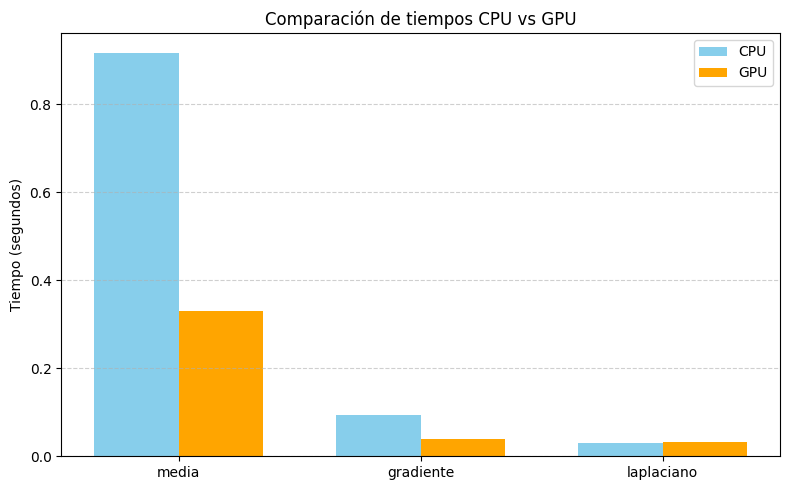

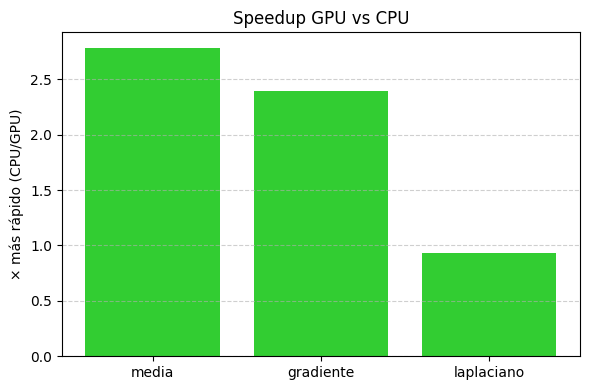

In [2]:
# ===============================================================
# DANAE
# ===============================================================

if __name__ == "__main__":
    FILENAME = "/home/cesar/Natural-Language-Processing-and-Computer-Vision/Visión-Computacional/Tarea-01-Filtros/imagenes/Danae.png"
    FILTROS = ['media', 'gradiente', 'laplaciano']
    HIPER = {'kernel_size': 20}

    # CPU
    img, res_cpu, t_cpu = apply_filters_cpu(FILENAME, FILTROS, modo_color=True, **HIPER)
    # GPU
    _, res_gpu, t_gpu = apply_filters_gpu(FILENAME, FILTROS, modo_color=True, **HIPER)

    mostrar_resultados(img, res_cpu, res_gpu, t_cpu, t_gpu)

-> CPU: media
-> CPU: gradiente
-> CPU: laplaciano
-> GPU: media
-> GPU: gradiente
-> GPU: laplaciano


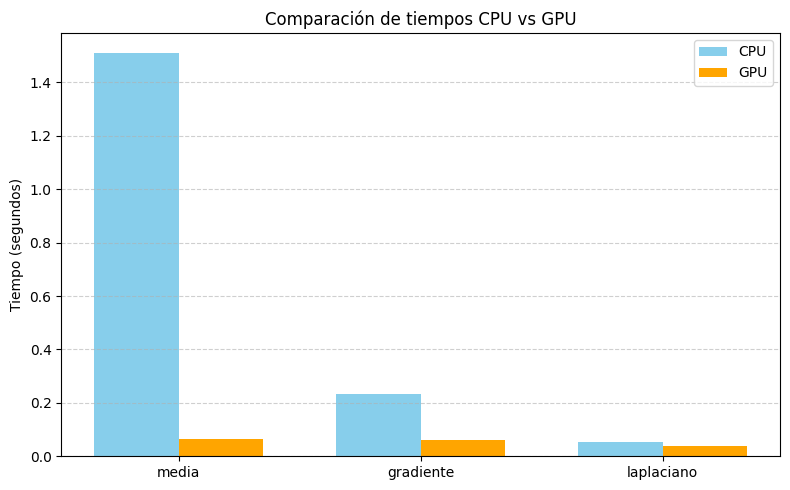

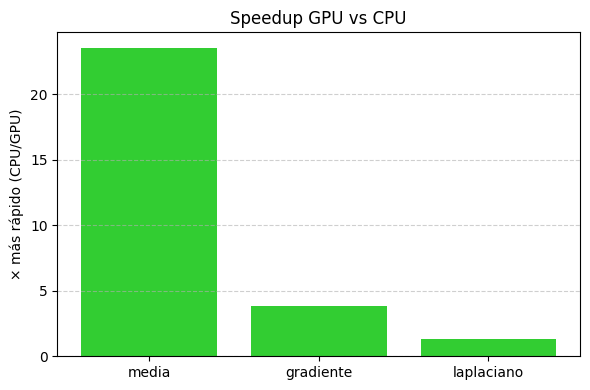

In [3]:
# ===============================================================
# MONET
# ===============================================================

if __name__ == "__main__":
    FILENAME = "/home/cesar/Natural-Language-Processing-and-Computer-Vision/Visión-Computacional/Tarea-01-Filtros/imagenes/Monet.jpg"
    FILTROS = ['media', 'gradiente', 'laplaciano']
    HIPER = {'kernel_size': 20}

    # CPU
    img, res_cpu, t_cpu = apply_filters_cpu(FILENAME, FILTROS, modo_color=True, **HIPER)
    # GPU
    _, res_gpu, t_gpu = apply_filters_gpu(FILENAME, FILTROS, modo_color=True, **HIPER)

    mostrar_resultados(img, res_cpu, res_gpu, t_cpu, t_gpu)

-> CPU: media
-> CPU: gradiente
-> CPU: laplaciano
-> GPU: media
-> GPU: gradiente
-> GPU: laplaciano


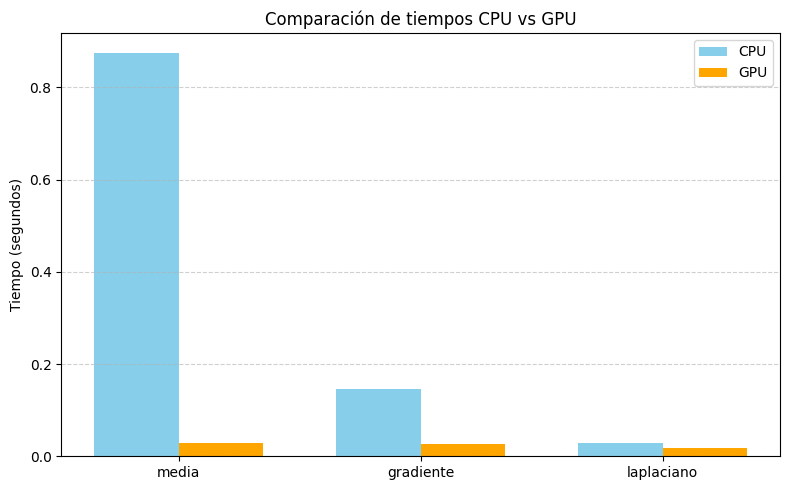

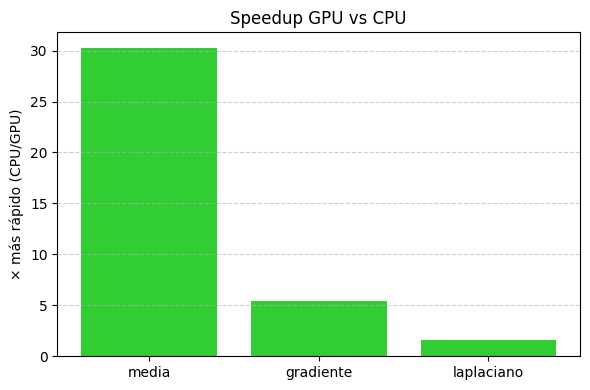

In [4]:
# ===============================================================
# LA OFRENDA
# ===============================================================

if __name__ == "__main__":
    FILENAME = "/home/cesar/Natural-Language-Processing-and-Computer-Vision/Visión-Computacional/Tarea-01-Filtros/imagenes/LaOfrenda_Saturnino.jpg"
    FILTROS = ['media', 'gradiente', 'laplaciano']
    HIPER = {'kernel_size': 20}

    # CPU
    img, res_cpu, t_cpu = apply_filters_cpu(FILENAME, FILTROS, modo_color=True, **HIPER)
    # GPU
    _, res_gpu, t_gpu = apply_filters_gpu(FILENAME, FILTROS, modo_color=True, **HIPER)

    mostrar_resultados(img, res_cpu, res_gpu, t_cpu, t_gpu)

-> CPU: media
-> CPU: gradiente
-> CPU: laplaciano
-> GPU: media
-> GPU: gradiente
-> GPU: laplaciano


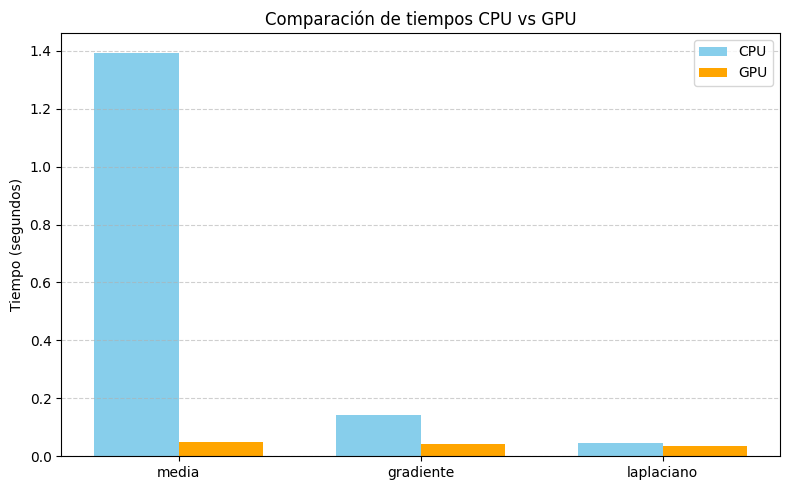

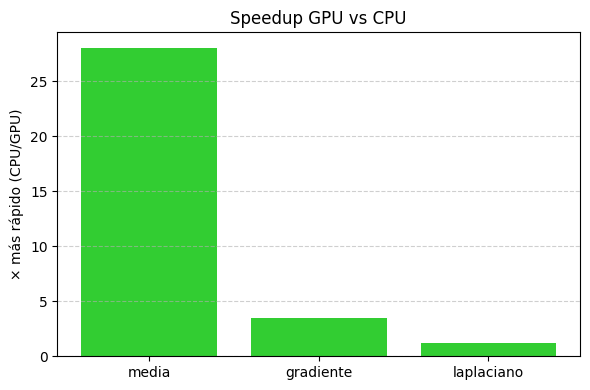

In [5]:
# ===============================================================
# Van Gogh
# ===============================================================

if __name__ == "__main__":
    FILENAME = "/home/cesar/Natural-Language-Processing-and-Computer-Vision/Visión-Computacional/Tarea-01-Filtros/imagenes/VanGogh.jpg"
    FILTROS = ['media', 'gradiente', 'laplaciano']
    HIPER = {'kernel_size': 20}

    # CPU
    img, res_cpu, t_cpu = apply_filters_cpu(FILENAME, FILTROS, modo_color=True, **HIPER)
    # GPU
    _, res_gpu, t_gpu = apply_filters_gpu(FILENAME, FILTROS, modo_color=True, **HIPER)

    mostrar_resultados(img, res_cpu, res_gpu, t_cpu, t_gpu)

-> CPU: media
-> CPU: gradiente
-> CPU: laplaciano
-> GPU: media
-> GPU: gradiente
-> GPU: laplaciano


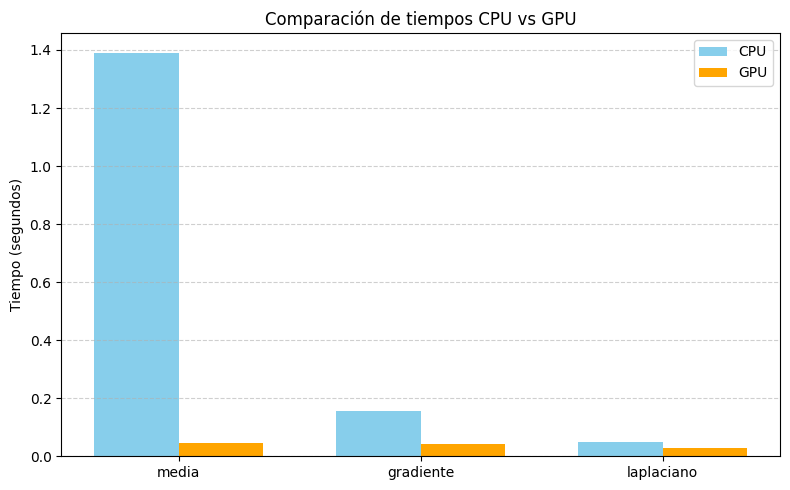

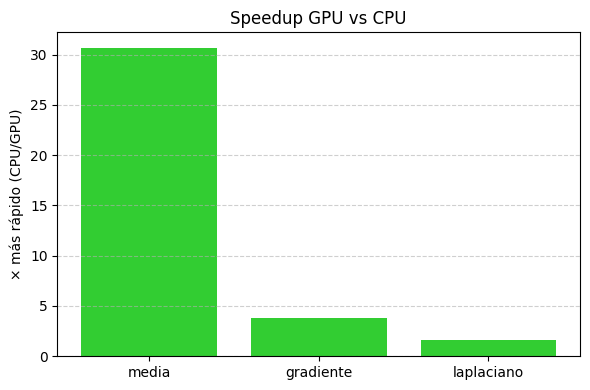

In [6]:
# ===============================================================
# Van Gogh 2
# ===============================================================

if __name__ == "__main__":
    FILENAME = "/home/cesar/Natural-Language-Processing-and-Computer-Vision/Visión-Computacional/Tarea-01-Filtros/imagenes/VanGogh2.jpg"
    FILTROS = ['media', 'gradiente', 'laplaciano']
    HIPER = {'kernel_size': 20}

    # CPU
    img, res_cpu, t_cpu = apply_filters_cpu(FILENAME, FILTROS, modo_color=True, **HIPER)
    # GPU
    _, res_gpu, t_gpu = apply_filters_gpu(FILENAME, FILTROS, modo_color=True, **HIPER)

    mostrar_resultados(img, res_cpu, res_gpu, t_cpu, t_gpu)